# Lab 4 (SOLUTION) — Analyse the Uploader Experiment Correctly
# المختبر 4 — تحليل تجربة رافع المستندات بشكل صحيح

**Module 4 · الوحدة 4 — Analysis Pitfalls: Peeking and Multiple Testing / مزالق التحليل: المراقبة المتكررة والاختبارات المتعددة**
SDA-DSC-213 · Experimentation, A/B Testing and Causal Inference · SDAIA Academy

---

### The experiment is over. Now do not ruin it.

Lab 2 designed it. Lab 3 powered it. The data is in: 80,000 assigned users, a clean SRM,
a frozen analysis plan. Everything from here is a chance to manufacture a wrong answer
that looks right.

This lab walks you into **two traps on purpose** before it tells you they are traps.
You will get a number, believe it, and then find out it was diluted. You will get a
confidence interval, believe it, and then find out it was half as wide as it should be.
That sequence is the lesson — a correct analysis is not a formula you apply, it is a set
of questions you ask before you apply one.

### What you will build

| # | Step | Minutes |
|---|---|---|
| 1 | The SRM gate, then the **all-assigned-users** estimate (**trap 1**) | 8 |
| 2 | The **triggered-users** estimate; two-proportion vs OLS + HC3 | 8 |
| 3 | **CUPED / covariate adjustment** — the same estimate, a tighter interval | 8 |
| 4 | The **guardrail family** under Bonferroni | 8 |
| 5 | The **segment sweep** under Benjamini–Hochberg | 8 |
| 6 | **Trap 2**: session-level analysis without clustering | 8 |
| 7 | The **peeking simulation**: 5% → 25% | 10 |
| 8 | The decision paragraph: statistical vs practical significance | 8 |

### The vocabulary this lab installs (bilingual, once)

- **peeking / optional stopping (المراقبة المتكررة / التوقف الاختياري)** — looking repeatedly and stopping at the first significant result.
- **multiple testing (الاختبارات المتعددة)** — every extra metric, arm and segment is another chance for noise to win.
- **FWER / family-wise error rate (معدل الخطأ على مستوى العائلة)** — P(any false positive); controlled by Bonferroni.
- **FDR / false discovery rate (معدل الاكتشافات الخاطئة)** — the expected share of false positives among discoveries; controlled by Benjamini–Hochberg.
- **clustered standard errors (الأخطاء المعيارية العنقودية)** — required when the analysis unit is finer than the randomisation unit.
- **practical significance (الدلالة العملية)** — big enough to act on, which is a different question from p < 0.05.

> All code, variables and comments stay in **English**.


---
## Step 0 — Open the frozen plan *before* you open the results

This is the discipline the whole module rests on. The plan was hashed in Lab 2 and has
not been touched since. Read it first, so that when a segment result gets exciting in
Step 5 you already know what you promised to do about it.


In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# Make `causal_utils` importable from anywhere under course_assets/
ROOT = Path.cwd()
while not (ROOT / "causal_utils").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
DATA = ROOT / "data"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from causal_utils import use_sdaia_style
use_sdaia_style()

RANDOM_SEED = 213          # fixed for every lab: reproducibility is graded
rng = np.random.default_rng(RANDOM_SEED)
print("Environment ready ·", ROOT)

Environment ready · /home/claude/course_assets


In [2]:
def needs(*values, msg="complete the TODO in the cell above, then re-run this cell"):
    """Guard for the start notebook: True (with a friendly note) if a TODO is unfinished."""
    if any(v is None for v in values):
        print(f"[not implemented yet] {msg}")
        return True
    return False

In [3]:
import json
from scipy import stats
from causal_utils import (srm_check, two_proportion_test, regression_effect,
                          correct_pvalues, peeking_simulation, cuped_adjust,
                          practical_significance_verdict, decision_plot, decision_memo,
                          AnalysisPlan, freeze_plan,
                          NAVY, BLUE, ORANGE, TEAL, SLATE, MUTED, PANEL)

with open(DATA / "GROUND_TRUTH.json") as f:
    GROUND_TRUTH = json.load(f)

plan_path = ROOT / "notebooks" / "lab2_frozen_plan.json"
if plan_path.exists():
    PLAN = json.loads(plan_path.read_text())
else:
    # Lab 2 was not run in this environment — rebuild the same plan so Lab 4 stands alone.
    PLAN = json.loads(freeze_plan(AnalysisPlan(
        experiment_name="injaz-guided-uploader-2026q2",
        decision="Ship the guided document uploader to all Injaz users?",
        randomisation_unit="user (national-ID hash)",
        oec="service-completion rate among triggered users",
        guardrails=["time-to-complete (session_duration_sec)", "support-contact rate",
                    "upload-error rate (error_flag)"],
        trigger_definition="user reaches the document-upload step at least once",
        unit_of_analysis="user", mde=0.02, alpha=0.05, power=0.80,
        correction_family=("no correction for the single OEC; Bonferroni across the "
                           "guardrail family; Benjamini-Hochberg for any segment sweep"),
        practical_threshold=0.01)).to_json())

print("FROZEN ANALYSIS PLAN (read before any outcome)")
print("=" * 66)
for k in ["experiment_name", "randomisation_unit", "unit_of_analysis", "oec",
          "trigger_definition", "mde", "alpha", "power", "practical_threshold",
          "correction_family", "stopping_rule", "plan_hash"]:
    print(f"  {k:<22}: {PLAN[k]}")
print("  guardrails            :")
for g in PLAN["guardrails"]:
    print(f"      - {g}")

THRESHOLD = PLAN["practical_threshold"]
ALPHA = PLAN["alpha"]

results = pd.read_csv(DATA / "injaz_experiment_results.csv")
print(f"\nassigned users in the results file : {len(results):,}")
print(f"columns                            : {list(results.columns)}")

FROZEN ANALYSIS PLAN (read before any outcome)
  experiment_name       : injaz-guided-uploader-2026q2
  randomisation_unit    : user (national-ID hash)
  unit_of_analysis      : user
  oec                   : service-completion rate among triggered users
  trigger_definition    : user reaches the document-upload step at least once
  mde                   : 0.02
  alpha                 : 0.05
  power                 : 0.8
  practical_threshold   : 0.01
  correction_family     : no correction for the single OEC; Bonferroni across the guardrail family; Benjamini-Hochberg for any segment sweep
  stopping_rule         : fixed horizon; no interim stopping for significance
  plan_hash             : b47e305fe7c01612
  guardrails            :
      - time-to-complete (session_duration_sec) - must not rise materially
      - support-contact rate - must not rise
      - upload-error rate (error_flag) - must not rise



assigned users in the results file : 80,000
columns                            : ['user_id', 'region', 'age', 'age_band', 'device', 'device_age_years', 'prior_sessions', 'prior_completion_rate', 'digital_literacy_score', 'signup_cohort', 'feature', 'variant', 'triggered', 'exposed', 'completed', 'support_contact', 'session_duration_sec', 'error_flag', 'drop_off']


---
## Step 1 *(8 min)* — The gate, then your first estimate

**The gate first.** Before any effect is computed, re-run the SRM check on the delivered
results. An SRM-failing experiment is not analysed — not "analysed with caveats", not
"analysed after weighting". Not analysed.

**Then the estimate.** You have 80,000 assigned users and a `completed` column. Compute
the lift. Do the obvious thing. We will come back to it.


In [4]:
# --- the gate -------------------------------------------------------------
srm = srm_check(results["variant"], {"control": 0.5, "treatment": 0.5})
print(srm)
assert srm.passed, "SRM FAILED — stop here and fix the pipeline. Do not analyse."
print("\nGate passed. Proceeding to the analysis.\n")

# --- the obvious estimate: everybody who was assigned ---------------------
est_all = two_proportion_test(results, "completed", "variant",
                              label="ALL assigned users")
print(est_all)
print()
print(f"Completion rate, control   : {results.loc[results.variant == 'control', 'completed'].mean():.4f}")
print(f"Completion rate, treatment : {results.loc[results.variant == 'treatment', 'completed'].mean():.4f}")
print()
print("Significant, positive, on 80,000 users. Write this number down — we will")
print("find out in Step 2 what is wrong with it.")

Sample Ratio Mismatch check: PASS
  chi2 = 0.16   p = 0.692
  treatment    observed   40,056   expected     40,000   (+0.14%)
  control      observed   39,944   expected     40,000   (-0.14%)

Gate passed. Proceeding to the analysis.

ALL assigned users (two-proportion z-test)
  effect : +1.34 pp [+0.65, +2.03]   (95% CI)
  se     : 0.00351    p = 0.0001376
  n      : treatment 40,056 / control 39,944

Completion rate, control   : 0.5528
Completion rate, treatment : 0.5662

Significant, positive, on 80,000 users. Write this number down — we will
find out in Step 2 what is wrong with it.


---
## Step 2 *(8 min)* — Trap 1: you analysed the wrong population

Go back to the frozen plan and read the trigger definition:

> *"user reaches the document-upload step at least once"*

A user who logged in, paid a fee and never touched a document **could not possibly have
been affected by a change to the document uploader**. They are in your denominator anyway,
contributing pure noise and a guaranteed zero effect.

This is not a rounding issue. The measured effect is diluted by roughly the trigger rate:

$$\hat\tau_{\text{all assigned}} \approx \text{trigger rate} \times \hat\tau_{\text{triggered}}$$

Compute the trigger rate, re-estimate on triggered users only, and compare. Then run the
same thing as an OLS regression with HC3 robust standard errors — the point estimate must
be **identical**, because a regression on a single binary indicator *is* a difference in
means. What the regression buys you is Step 3.


In [5]:
trigger_rate = results["triggered"].mean()
triggered = results.loc[results["triggered"] == 1].copy()

est_trig = two_proportion_test(triggered, "completed", "variant",
                               label="TRIGGERED users (the OEC population)")
est_ols = regression_effect(triggered, "completed", "variant",
                            label="TRIGGERED users, OLS + HC3")

print(f"trigger rate                     : {trigger_rate:.4f}")
print(f"assigned users                   : {len(results):,}")
print(f"triggered users (the denominator): {len(triggered):,}\n")

print(est_all)
print()
print(est_trig)
print()
print(est_ols)
print()
print(f"point estimates identical (two-prop vs OLS): "
      f"{abs(est_trig.estimate - est_ols.estimate) < 1e-9}")
print()
print("The dilution arithmetic:")
print(f"  triggered estimate x trigger rate = {est_trig.estimate:.4f} x {trigger_rate:.4f} "
      f"= {est_trig.estimate * trigger_rate:.4f}")
print(f"  all-assigned estimate             = {est_all.estimate:.4f}")
print()
print("The 'all assigned' number was not wrong arithmetic. It was the right answer to")
print("the wrong question: 'what happens to completion across the whole platform if we")
print("ship this?' — which is a legitimate question, but it is not the OEC we froze, and")
print("it is not the number you use to judge whether the FEATURE works.")

trigger rate                     : 0.6207
assigned users                   : 80,000
triggered users (the denominator): 49,653

ALL assigned users (two-proportion z-test)
  effect : +1.34 pp [+0.65, +2.03]   (95% CI)
  se     : 0.00351    p = 0.0001376
  n      : treatment 40,056 / control 39,944

TRIGGERED users (the OEC population) (two-proportion z-test)
  effect : +2.16 pp [+1.29, +3.04]   (95% CI)
  se     : 0.00445    p = 1.17e-06
  n      : treatment 24,838 / control 24,815

TRIGGERED users, OLS + HC3 (OLS + HC3 robust SE)
  effect : +2.16 pp [+1.29, +3.04]   (95% CI)
  se     : 0.00445    p = 1.165e-06
  n      : treatment 24,838 / control 24,815

point estimates identical (two-prop vs OLS): True

The dilution arithmetic:
  triggered estimate x trigger rate = 0.0216 x 0.6207 = 0.0134
  all-assigned estimate             = 0.0134

The 'all assigned' number was not wrong arithmetic. It was the right answer to
the wrong question: 'what happens to completion across the whole platform

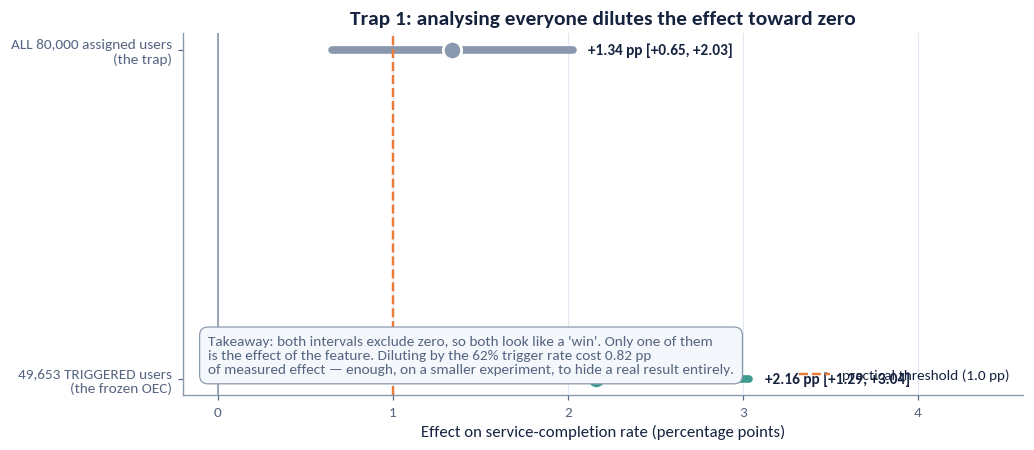

In [6]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))
labels = ["ALL 80,000 assigned users\n(the trap)", "49,653 TRIGGERED users\n(the frozen OEC)"]
ests = [est_all, est_trig]
colours = [MUTED, TEAL]
for i, (e, colour) in enumerate(zip(ests, colours)):
    y = 1 - i
    ax.plot([100 * e.ci_low, 100 * e.ci_high], [y, y], color=colour, lw=5,
            solid_capstyle="round")
    ax.plot([100 * e.estimate], [y], "o", color=colour, ms=12,
            markeredgecolor="white", markeredgewidth=1.8)
    ax.text(100 * e.ci_high + 0.09, y, f"{100*e.estimate:+.2f} pp "
            f"[{100*e.ci_low:+.2f}, {100*e.ci_high:+.2f}]",
            va="center", fontsize=10, color=NAVY, fontweight="bold")

ax.axvline(0, color=MUTED, lw=1.1)
ax.axvline(100 * THRESHOLD, color=ORANGE, ls="--", lw=1.6,
           label=f"practical threshold ({100*THRESHOLD:.1f} pp)")
ax.set_yticks([0, 1]); ax.set_yticklabels(labels[::-1])
ax.set_xlabel("Effect on service-completion rate (percentage points)")
ax.set_title("Trap 1: analysing everyone dilutes the effect toward zero")
ax.set_xlim(-0.2, 4.6)
ax.legend(loc="lower right")
ax.grid(axis="y", visible=False)
ax.annotate(
    f"Takeaway: both intervals exclude zero, so both look like a 'win'. Only one of them\n"
    f"is the effect of the feature. Diluting by the {trigger_rate:.0%} trigger rate cost "
    f"{100*(est_trig.estimate - est_all.estimate):.2f} pp\nof measured effect — enough, on a "
    "smaller experiment, to hide a real result entirely.",
    xy=(0.03, 0.06), xycoords="axes fraction", fontsize=10, color=SLATE,
    bbox=dict(boxstyle="round,pad=0.55", fc=PANEL, ec=MUTED, lw=0.8))
plt.tight_layout()
plt.show()

> ### Instructor note — Steps 1–2
>
> **Teaching point.** All assigned: **+1.34 pp [+0.65, +2.03]**. Triggered:
> **+2.16 pp [+1.29, +3.04]**. Both are significant, so nobody's alarm goes off — that is
> precisely why this trap survives in production. Do the dilution arithmetic on the board:
> 2.16 × 0.6207 = 1.34, exactly the all-assigned figure, because the non-triggered
> stratum is a clean null (−0.007 pp). The mechanism, not the arithmetic, is the point.
>
> **Common wrong answer.** "So triggered is always right." No — *both* numbers are real
> answers to different questions. All-assigned is the intent-to-treat effect on the whole
> platform and is the right input to a capacity plan. Triggered is the effect of the
> feature and is the right input to a ship decision. The sin is not knowing which one you
> computed.
>
> **When a participant is stuck.** If their OLS estimate differs from the two-proportion
> one, they almost certainly used `variant` as a string without `C()`, or reversed the
> reference level so the sign flipped. Have them print the model's parameter names.

### ✅ Checkpoint A — what you should be seeing by now

≈16 minutes in. SRM passing, an all-assigned estimate around +1.34 pp, and a triggered
estimate around +2.16 pp with identical two-proportion and OLS point estimates.


In [7]:
def checkpoint_a():
    if est_trig is None:
        print("✗ Steps 1-2 incomplete.")
        return
    print(f"✓ SRM gate               : {'PASS' if srm.passed else 'FAIL'} "
          f"(chi2 {srm.chi2:.2f}, p {srm.p_value:.3f})")
    print(f"✓ all assigned (diluted) : {est_all.as_pp()}")
    print(f"✓ triggered (the OEC)    : {est_trig.as_pp()}")
    print(f"✓ OLS + HC3 agrees       : {abs(est_trig.estimate - est_ols.estimate) < 1e-9}")
    print(f"✓ trigger rate           : {trigger_rate:.4f}")
    print()
    print("Next: the same estimate with a tighter interval, then the guardrails.")

checkpoint_a()

✓ SRM gate               : PASS (chi2 0.16, p 0.692)
✓ all assigned (diluted) : +1.34 pp [+0.65, +2.03]
✓ triggered (the OEC)    : +2.16 pp [+1.29, +3.04]
✓ OLS + HC3 agrees       : True
✓ trigger rate           : 0.6207

Next: the same estimate with a tighter interval, then the guardrails.


---
## Step 3 *(8 min)* — Same estimate, tighter interval

Lab 3 measured a 14% variance reduction from `prior_completion_rate`. Now spend it.

Adding a **pre-treatment** covariate to the regression cannot bias a randomised
comparison — treatment is independent of it by construction — but it absorbs residual
variance and narrows the interval. That is the entire CUPED bargain, and the one
condition that makes it safe is that the covariate was measured *before* assignment.

> ⚠️ Never put a **post-treatment** variable in the covariate list. `support_contact`,
> `session_duration_sec` and `error_flag` are all downstream of the treatment. Adjusting
> for them is Module 6's mediator/collider trap and it will quietly destroy the estimate.
> The cell after the good one demonstrates exactly that.


In [8]:
est_cuped = regression_effect(
    triggered, "completed", "variant", covariates=["prior_completion_rate"],
    label="TRIGGERED + pre-period covariate (CUPED-style)")

width_plain = est_trig.ci_high - est_trig.ci_low
width_cuped = est_cuped.ci_high - est_cuped.ci_low

print(est_trig); print(); print(est_cuped)
print()
print(f"{'':<34}{'estimate':>12}{'SE':>10}{'CI width':>12}")
print("-" * 70)
print(f"{'unadjusted':<34}{100*est_trig.estimate:>11.2f}pp{est_trig.se:>10.5f}"
      f"{100*width_plain:>11.2f}pp")
print(f"{'+ prior_completion_rate':<34}{100*est_cuped.estimate:>11.2f}pp{est_cuped.se:>10.5f}"
      f"{100*width_cuped:>11.2f}pp")
print()
print(f"interval narrowed by {1 - width_cuped / width_plain:.1%}   "
      f"(variance reduction {1 - (est_cuped.se / est_trig.se)**2:.1%})")
print(f"equivalent to running the experiment on "
      f"{(est_trig.se / est_cuped.se)**2:.2f}x as many users, for free")

# --- what NOT to do: adjust for a POST-treatment variable ----------------
bad = regression_effect(triggered, "completed", "variant",
                        covariates=["prior_completion_rate", "drop_off"],
                        label="WRONG: drop_off (post-treatment) included")
print("\n" + "=" * 70)
print("WHAT NOT TO DO — 'controlling for more' by adding a post-treatment variable:")
print(bad)
print(f"\nThe estimate collapsed from {100*est_cuped.estimate:+.2f} pp to "
      f"{100*bad.estimate:+.2f} pp — {1 - bad.estimate / est_cuped.estimate:.0%} of the "
      "effect has vanished.")
print()
print("Why: `drop_off` is a CONSEQUENCE of the treatment, and it is most of the causal")
print("path. The guided uploader works BY reducing drop-off "
      f"({100*(triggered.loc[triggered.variant=='treatment','drop_off'].mean() - triggered.loc[triggered.variant=='control','drop_off'].mean()):+.2f} pp),")
print("and reduced drop-off is what raises completion. Holding drop-off fixed and then")
print("asking 'what is left of the effect?' asks the uploader to work through a channel")
print("we have just closed. Module 6 gives this its proper name (the mediator trap);")
print("for now the rule is enough: PRE-TREATMENT covariates only, always.")

TRIGGERED users (the OEC population) (two-proportion z-test)
  effect : +2.16 pp [+1.29, +3.04]   (95% CI)
  se     : 0.00445    p = 1.17e-06
  n      : treatment 24,838 / control 24,815

TRIGGERED + pre-period covariate (CUPED-style) (OLS + HC3 robust SE)
  effect : +2.07 pp [+1.26, +2.88]   (95% CI)
  se     : 0.00414    p = 5.932e-07
  n      : treatment 24,838 / control 24,815

                                      estimate        SE    CI width
----------------------------------------------------------------------
unadjusted                               2.16pp   0.00445       1.74pp
+ prior_completion_rate                  2.07pp   0.00414       1.62pp

interval narrowed by 7.0%   (variance reduction 13.5%)
equivalent to running the experiment on 1.16x as many users, for free



WHAT NOT TO DO — 'controlling for more' by adding a post-treatment variable:
WRONG: drop_off (post-treatment) included (OLS + HC3 robust SE)
  effect : +0.91 pp [+0.37, +1.45]   (95% CI)
  se     : 0.00276    p = 0.0009442
  n      : treatment 24,838 / control 24,815

The estimate collapsed from +2.07 pp to +0.91 pp — 56% of the effect has vanished.

Why: `drop_off` is a CONSEQUENCE of the treatment, and it is most of the causal
path. The guided uploader works BY reducing drop-off (-1.56 pp),
and reduced drop-off is what raises completion. Holding drop-off fixed and then
asking 'what is left of the effect?' asks the uploader to work through a channel
we have just closed. Module 6 gives this its proper name (the mediator trap);
for now the rule is enough: PRE-TREATMENT covariates only, always.


> ### Instructor note — Step 3
>
> **Teaching point.** The interval goes from **[+1.29, +3.04]** to **[+1.26, +2.88]** —
> the SE drops from 0.00445 to 0.00414, a 13.5% variance reduction that lands exactly on
> Lab 3's CUPED number. Point out that the estimate itself barely moves (+2.16 → +2.07 pp):
> adjustment buys precision, not a different answer. That is how you know it is legitimate.
>
> **Common wrong answer.** "If one covariate helps, let's add all of them." The
> post-treatment demonstration is there for exactly this moment: adding `drop_off` collapses
> the estimate from **+2.07 pp to +0.91 pp** — 56% of the effect gone. Let the room watch
> the number move *before* you name the mechanism, then name it: the uploader works *by*
> reducing drop-off, so conditioning on drop-off closes the very channel you are measuring.
>
> **When a participant is stuck.** If the interval got *wider*, they adjusted for
> something uncorrelated (or a constant). Have them check
> `triggered[["completed", "prior_completion_rate"]].corr()` — around 0.37 is what buys the 13.5%.

---
## Step 4 *(8 min)* — The guardrail family, under Bonferroni

A feature that lifts completion while doubling support load has not succeeded. The frozen
plan names three guardrails, and the frozen correction family for them is **Bonferroni**:
a guardrail breach is expensive, so you want to control the probability of **any** false
alarm, not the expected proportion of them.

Note the asymmetry in how you read guardrails. For the OEC you ask "is there an effect?".
For a guardrail you ask "can I rule out a harmful effect large enough to matter?" — a
question about the interval, not the p-value.


In [9]:
guardrails = []

for metric, label, direction in [
        ("support_contact", "support-contact rate", "lower is better"),
        ("error_flag", "upload-error rate", "lower is better"),
        ("drop_off", "step drop-off rate", "lower is better")]:
    e = two_proportion_test(triggered, metric, "variant", label=label)
    guardrails.append({"metric": label, "direction": direction,
                       "estimate": e.estimate, "ci_low": e.ci_low,
                       "ci_high": e.ci_high, "p_raw": e.p_value, "obj": e})

# time-to-complete is a mean, not a proportion -> Welch t-test
t_dur = triggered.loc[triggered.variant == "treatment", "session_duration_sec"]
c_dur = triggered.loc[triggered.variant == "control", "session_duration_sec"]
tt = stats.ttest_ind(t_dur, c_dur, equal_var=False)
se_dur = np.sqrt(t_dur.var(ddof=1) / len(t_dur) + c_dur.var(ddof=1) / len(c_dur))
diff_dur = float(t_dur.mean() - c_dur.mean())
guardrails.append({"metric": "time-to-complete (seconds)", "direction": "lower is better",
                   "estimate": diff_dur, "ci_low": diff_dur - 1.96 * se_dur,
                   "ci_high": diff_dur + 1.96 * se_dur, "p_raw": float(tt.pvalue),
                   "obj": None})

gdf = pd.DataFrame(guardrails)
corrected = correct_pvalues(gdf["p_raw"].to_numpy(), gdf["metric"].to_numpy(),
                            method="bonferroni", alpha=ALPHA)
gdf = gdf.merge(corrected[["metric", "p_adjusted", "reject"]], on="metric")

print("GUARDRAIL FAMILY — Bonferroni, m = 4\n")
print(f"{'metric':<28}{'effect':>16}{'p raw':>10}{'p adj':>10}   verdict")
print("-" * 80)
for _, r in gdf.sort_values("p_raw").iterrows():
    unit = " s" if "seconds" in r["metric"] else "pp"
    scale = 1 if "seconds" in r["metric"] else 100
    flag = "MOVED" if r["reject"] else "no evidence of change"
    print(f"{r['metric']:<28}{scale*r['estimate']:>13.2f}{unit:>3}"
          f"{r['p_raw']:>10.4f}{r['p_adjusted']:>10.4f}   {flag}")

print()
print("Reading the family, in the order that matters:")
print(f"  - step drop-off FELL {100*abs(gdf.loc[gdf.metric == 'step drop-off rate', 'estimate'].iloc[0]):.2f} pp "
      "— that is the mechanism behind the OEC win, not a breach.")
print(f"  - support contacts FELL 0.54 pp and survive correction; upload errors are flat "
      "(raw p 0.86, adjusted 1.00).")
print(f"  - time-to-complete ROSE {diff_dur:.1f} s and survives Bonferroni.")
print()
mean_dur = c_dur.mean()
print(f"That last one is the interesting case. {diff_dur:.1f} s on a "
      f"{mean_dur:.0f} s baseline is a {diff_dur/mean_dur:.1%} increase: highly")
print("significant on 49,653 users, and almost certainly irrelevant to a citizen. A")
print("guardrail is a business threshold, not a p-value. Ours was 'must not rise")
print("materially'; 4.4 seconds is not material, and the memo should say so explicitly")
print("rather than quietly dropping the row.")

GUARDRAIL FAMILY — Bonferroni, m = 4

metric                                effect     p raw     p adj   verdict
--------------------------------------------------------------------------------
time-to-complete (seconds)           4.42  s    0.0000    0.0000   MOVED
step drop-off rate                  -1.56 pp    0.0002    0.0007   MOVED
support-contact rate                -0.54 pp    0.0018    0.0073   MOVED
upload-error rate                    0.03 pp    0.8645    1.0000   no evidence of change

Reading the family, in the order that matters:
  - step drop-off FELL 1.56 pp — that is the mechanism behind the OEC win, not a breach.
  - support contacts FELL 0.54 pp and survive correction; upload errors are flat (raw p 0.86, adjusted 1.00).
  - time-to-complete ROSE 4.4 s and survives Bonferroni.

That last one is the interesting case. 4.4 s on a 159 s baseline is a 2.8% increase: highly
significant on 49,653 users, and almost certainly irrelevant to a citizen. A
guardrail is a business 

> ### Instructor note — Step 4
>
> **Teaching point.** This family is a gift, because it contains all three cases at once.
> Drop-off falls 1.56 pp (the mechanism behind the win) and support contacts fall 0.54 pp;
> both **survive Bonferroni**. Upload errors sit at raw p = 0.86 and go nowhere.
> Time-to-complete rises 4.4 seconds and **survives** at raw p ≈ 4.8 × 10⁻⁸.
>
> **Common wrong answer.** "Time-to-complete is significant, so the guardrail is breached,
> so we don't ship." Push back: 4.4 s on a 159 s baseline is 2.8%. Statistical significance
> on 49,653 users is not the question; the guardrail said "must not rise *materially*". If
> the room cannot decide, that is the real finding — the threshold should have been a
> number in the frozen plan, and next time it will be.
>
> **When a participant is stuck.** People try to run `two_proportion_test` on
> `session_duration_sec`. It is a mean of seconds, not a rate — the function will produce
> nonsense rather than an error, which is itself worth pointing at.

---
## Step 5 *(8 min)* — The segment sweep, and the segment that vanishes

Now the exploratory sweep: 13 regions × devices, about 16 tests. Under the null, 16 tests
at α = 0.05 give a **56%** chance of at least one false positive. Every extra segment is
another lottery ticket.

The frozen plan says the sweep gets **Benjamini–Hochberg**: this is an exploratory
hypothesis list, not a guardrail family, so controlling the *expected proportion* of false
discoveries is the right trade — more power than Bonferroni, at the cost of tolerating
some false discoveries.

Run it. Get excited about a segment. Then correct it.


In [10]:
rows = []
for col in ["region", "device"]:
    for level in sorted(triggered[col].unique()):
        sub = triggered.loc[triggered[col] == level]
        if sub["variant"].nunique() < 2 or len(sub) < 200:
            continue
        e = two_proportion_test(sub, "completed", "variant", label=f"{col}={level}")
        rows.append({"segment": e.label, "n": len(sub), "estimate": e.estimate,
                     "ci_low": e.ci_low, "ci_high": e.ci_high, "p_raw": e.p_value})

sweep = pd.DataFrame(rows)
bh = correct_pvalues(sweep["p_raw"].to_numpy(), sweep["segment"].to_numpy(),
                     method="bh", alpha=ALPHA)
sweep = sweep.merge(bh[["metric", "p_adjusted", "reject"]],
                    left_on="segment", right_on="metric").drop(columns="metric")
sweep = sweep.sort_values("p_raw").reset_index(drop=True)

print(f"tests in the family : {len(sweep)}")
print(f"P(at least one false positive if NOTHING is real) = "
      f"1 - 0.95^{len(sweep)} = {1 - 0.95**len(sweep):.0%}\n")

print(f"{'segment':<26}{'n':>8}{'effect':>10}{'p raw':>10}{'p BH':>10}  survives?")
print("-" * 76)
for _, r in sweep.iterrows():
    print(f"{r['segment']:<26}{r['n']:>8,}{100*r['estimate']:>9.2f}pp"
          f"{r['p_raw']:>10.4f}{r['p_adjusted']:>10.4f}  "
          f"{'YES' if r['reject'] else '-'}")

raw_sig = int((sweep["p_raw"] < ALPHA).sum())
survive = int(sweep["reject"].sum())
print()
print(f"raw-significant segments : {raw_sig}")
print(f"surviving BH             : {survive}")
print()
# Take the strongest segment that actually SURVIVES the correction; if none
# survives, take the most significant raw one. Never hard-code a row index --
# which row is "the exciting one" is a property of the data, not of the code.
survivors = sweep[sweep["reject"]]
star = survivors.iloc[0] if len(survivors) else sweep.iloc[0]
verdict = "It survives BH" if bool(star["reject"]) else "It does NOT survive BH"
print(f"The exciting one: {star['segment']} at {100*star['estimate']:+.2f} pp, "
      f"raw p = {star['p_raw']:.4f}, n = {star['n']:,}.")
print(f"{verdict} — and it is STILL only a hypothesis. Three reasons:")
print("  1. It was not pre-registered; we went looking for it after seeing the data.")
print("  2. The overall effect is positive, so a large positive segment estimate is what")
print("     you expect from noise around a real effect, not evidence of heterogeneity.")
print(f"  3. On n = {star['n']:,} the interval is "
      f"[{100*star['ci_low']:+.2f}, {100*star['ci_high']:+.2f}] pp — wide enough to be")
print("     consistent with the platform-wide effect.")
print()
print("The only way to promote a swept segment to a finding is a fresh, pre-registered")
print("experiment in that segment. Write it on the roadmap, not in the recommendation.")

tests in the family : 16
P(at least one false positive if NOTHING is real) = 1 - 0.95^16 = 56%

segment                          n    effect     p raw      p BH  survives?
----------------------------------------------------------------------------
device=ios                  24,473     2.25pp    0.0004    0.0060  YES
device=android              18,206     1.98pp    0.0071    0.0504  -
region=Hail                    976     7.94pp    0.0129    0.0504  -
region=Makkah               12,432     2.16pp    0.0145    0.0504  -
region=Qassim                2,511     4.81pp    0.0158    0.0504  -
region=Northern Borders        497     8.93pp    0.0460    0.1011  -
region=Riyadh               12,957     1.71pp    0.0487    0.1011  -
device=desktop               6,974     2.32pp    0.0505    0.1011  -
region=Madinah               3,433     2.97pp    0.0814    0.1447  -
region=Tabuk                 1,484     4.23pp    0.1019    0.1590  -
region=Al Jouf                 473     7.34pp    0.1093    

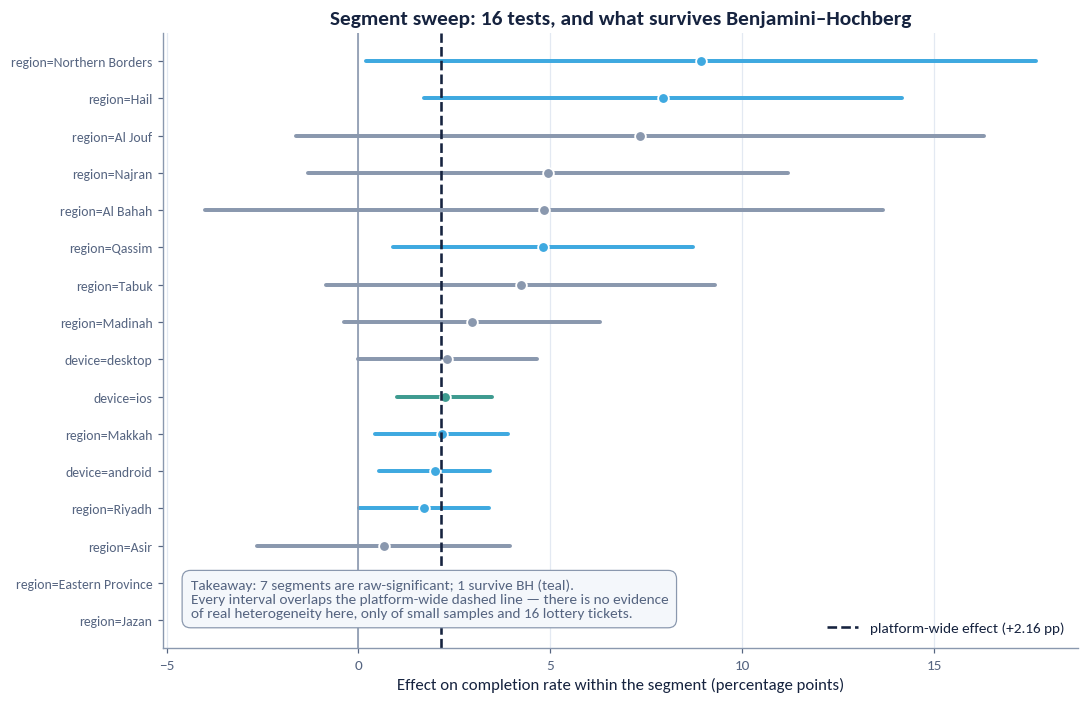

In [11]:
fig, ax = plt.subplots(figsize=(10, 6.5))
s = sweep.sort_values("estimate").reset_index(drop=True)
for i, r in s.iterrows():
    colour = TEAL if r["reject"] else (BLUE if r["p_raw"] < ALPHA else MUTED)
    ax.plot([100 * r["ci_low"], 100 * r["ci_high"]], [i, i], color=colour, lw=2.6,
            solid_capstyle="round")
    ax.plot([100 * r["estimate"]], [i], "o", color=colour, ms=7,
            markeredgecolor="white", markeredgewidth=1.2)

ax.axvline(0, color=MUTED, lw=1.1)
ax.axvline(100 * est_trig.estimate, color=NAVY, ls="--", lw=1.7,
           label=f"platform-wide effect ({100*est_trig.estimate:+.2f} pp)")
ax.set_yticks(range(len(s)))
ax.set_yticklabels(s["segment"], fontsize=9)
ax.set_xlabel("Effect on completion rate within the segment (percentage points)")
ax.set_title("Segment sweep: 16 tests, and what survives Benjamini–Hochberg")
ax.legend(loc="lower right")
ax.grid(axis="y", visible=False)
ax.annotate(
    f"Takeaway: {int((sweep['p_raw'] < ALPHA).sum())} segments are raw-significant; "
    f"{int(sweep['reject'].sum())} survive BH (teal).\n"
    "Every interval overlaps the platform-wide dashed line — there is no evidence\n"
    "of real heterogeneity here, only of small samples and 16 lottery tickets.",
    xy=(0.03, 0.05), xycoords="axes fraction", fontsize=10, color=SLATE,
    bbox=dict(boxstyle="round,pad=0.55", fc=PANEL, ec=MUTED, lw=0.8))
plt.tight_layout()
plt.show()

> ### Instructor note — Step 5
>
> **Teaching point.** This is the highest-value moment in the lab. Seven segments are
> raw-significant; **one** survives BH. Let a pair announce "it works brilliantly in
> Northern Borders, +8.9 points!" *before* you run the correction, then run it. Northern
> Borders dies under BH; `device=ios` is the single survivor — which sets up the harder
> question of why even a *surviving* sweep result is still not a finding.
>
> **Common wrong answer.** "BH kept it, so it's real, let's target iOS." Three counters,
> in this order: it was not pre-registered; its interval overlaps the platform-wide effect
> so there is no evidence it differs; and n = 24,473 in a positive-effect experiment will
> throw up large segment estimates by construction. The correction controls the error rate
> of the *procedure*; it does not turn an exploratory result into a confirmatory one.
>
> **When a participant is stuck.** If every segment comes out significant, they forgot the
> correction entirely. If none does, they applied Bonferroni instead of BH — worth showing
> both so the power difference between FWER and FDR is concrete.

---
## Step 6 *(8 min)* — Trap 2: the unit-of-analysis mismatch

Open `injaz_sessions.csv.gz`: 339,017 sessions from the same 80,000 users, about 4.2
sessions each. A colleague analyses completion **per session**, because "more rows means
more power".

More rows, yes. More *information*, no. Sessions within a user are correlated — the same
person, the same device, the same habits — so treating 339,017 sessions as independent
observations of a **user-randomised** experiment produces a standard error that is far too
small and a confidence interval that lies about precision.

Three analyses, one truth:

1. **Session-level, no clustering** — the seductive, wrong one.
2. **Session-level, clustered by `user_id`** — honest.
3. **Aggregated to the user, then analysed** — also honest, and simpler to explain.

The point estimate barely moves. The interval is the whole story.


In [12]:
sessions = pd.read_csv(DATA / "injaz_sessions.csv.gz")
print(f"sessions            : {len(sessions):,}")
print(f"distinct users      : {sessions['user_id'].nunique():,}")
print(f"sessions per user   : {len(sessions) / sessions['user_id'].nunique():.2f}\n")

naive_sess = two_proportion_test(sessions, "session_completed", "variant",
                                 label="session-level, NO clustering (wrong)")
clustered = regression_effect(sessions, "session_completed", "variant",
                              cluster="user_id",
                              label="session-level, clustered by user")
user_level = sessions.groupby(["user_id", "variant"], as_index=False)["session_completed"].mean()
aggregated = regression_effect(user_level, "session_completed", "variant",
                               label="aggregated to the user, then analysed")

print(naive_sess); print(); print(clustered); print(); print(aggregated)
print()
print(f"{'analysis':<42}{'estimate':>11}{'SE':>10}{'CI width':>12}")
print("-" * 78)
for e in (naive_sess, clustered, aggregated):
    print(f"{e.label:<42}{100*e.estimate:>10.2f}pp{e.se:>10.5f}"
          f"{100*(e.ci_high - e.ci_low):>11.2f}pp")
print()
print(f"Ignoring clustering understates the standard error by a factor of "
      f"{clustered.se / naive_sess.se:.2f}x.")
print(f"The design effect is roughly 1 + (m - 1) * ICC with m = "
      f"{len(sessions) / sessions['user_id'].nunique():.1f} sessions per user.")
print()
print("Note what did NOT change: the point estimate is +0.86 pp in both session-level rows. The bug is")
print("never in the effect, it is always in the uncertainty — which is exactly the part")
print("a decision-maker uses to decide.")

sessions            : 339,017
distinct users      : 80,000
sessions per user   : 4.24



session-level, NO clustering (wrong) (two-proportion z-test)
  effect : +0.86 pp [+0.53, +1.18]   (95% CI)
  se     : 0.00166    p = 2.36e-07
  n      : treatment 169,422 / control 169,595

session-level, clustered by user (OLS + cluster-robust SE (user_id))
  effect : +0.86 pp [+0.33, +1.38]   (95% CI)
  se     : 0.00267    p = 0.001349
  n      : treatment 169,422 / control 169,595

aggregated to the user, then analysed (OLS + HC3 robust SE)
  effect : +1.17 pp [+0.66, +1.69]   (95% CI)
  se     : 0.00261    p = 6.858e-06
  n      : treatment 40,056 / control 39,944

analysis                                     estimate        SE    CI width
------------------------------------------------------------------------------
session-level, NO clustering (wrong)            0.86pp   0.00166       0.65pp
session-level, clustered by user                0.86pp   0.00267       1.05pp
aggregated to the user, then analysed           1.17pp   0.00261       1.02pp

Ignoring clustering understates th

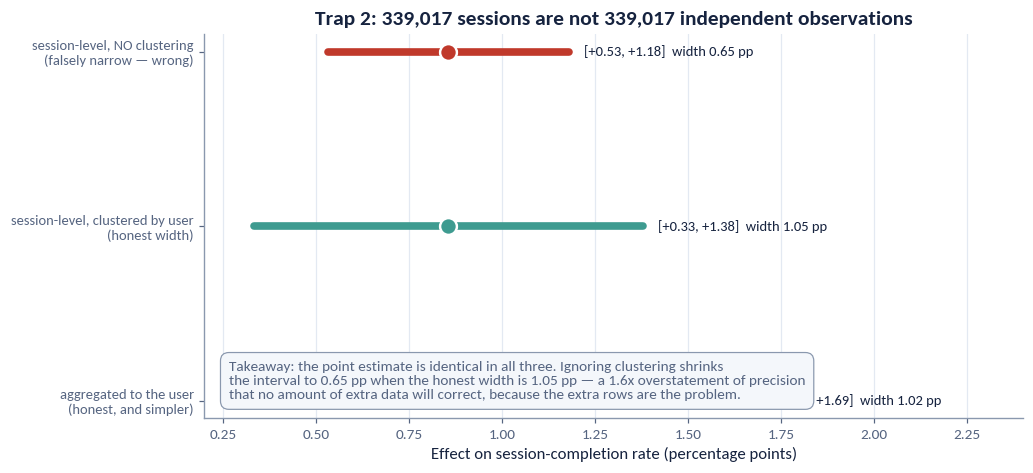

In [13]:
fig, ax = plt.subplots(figsize=(9.5, 4.4))
items = [(naive_sess, "#C0392B", "session-level, NO clustering\n(falsely narrow — wrong)"),
         (clustered, TEAL, "session-level, clustered by user\n(honest width)"),
         (aggregated, BLUE, "aggregated to the user\n(honest, and simpler)")]
for i, (e, colour, label) in enumerate(items):
    y = len(items) - 1 - i
    ax.plot([100 * e.ci_low, 100 * e.ci_high], [y, y], color=colour, lw=5,
            solid_capstyle="round")
    ax.plot([100 * e.estimate], [y], "o", color=colour, ms=11,
            markeredgecolor="white", markeredgewidth=1.6)
    ax.text(100 * e.ci_high + 0.04, y,
            f"[{100*e.ci_low:+.2f}, {100*e.ci_high:+.2f}]  width "
            f"{100*(e.ci_high - e.ci_low):.2f} pp",
            va="center", fontsize=9.5, color=NAVY)

ax.axvline(0, color=MUTED, lw=1.1)
ax.set_yticks(range(len(items)))
ax.set_yticklabels([lbl for _, _, lbl in items][::-1], fontsize=9.5)
ax.set_xlabel("Effect on session-completion rate (percentage points)")
ax.set_title("Trap 2: 339,017 sessions are not 339,017 independent observations")
ax.set_xlim(0.2, 2.4)
ax.grid(axis="y", visible=False)
ax.annotate(
    f"Takeaway: the point estimate is identical in all three. Ignoring clustering shrinks\n"
    f"the interval to {100*(naive_sess.ci_high - naive_sess.ci_low):.2f} pp when the honest "
    f"width is {100*(clustered.ci_high - clustered.ci_low):.2f} pp — a "
    f"{clustered.se / naive_sess.se:.1f}x overstatement of precision\n"
    "that no amount of extra data will correct, because the extra rows are the problem.",
    xy=(0.03, 0.05), xycoords="axes fraction", fontsize=10, color=SLATE,
    bbox=dict(boxstyle="round,pad=0.55", fc=PANEL, ec=MUTED, lw=0.8))
plt.tight_layout()
plt.show()

> ### Instructor note — Step 6
>
> **Teaching point.** SE goes from **0.00166** to **0.00267** — a 1.61× understatement, and
> the aggregated-to-user analysis lands on the clustered one (SE 0.00261), which is the
> proof that clustering is not a fudge factor but a correction toward the truth. Say the
> sentence: *the rows you added were not new information, they were the same people again.*
>
> **Common wrong answer.** "We have 339k rows, so this is the more powerful analysis."
> Ask how many coin flips there were. Eighty thousand. That is the information content,
> whatever the row count says.
>
> **When a participant is stuck.** `regression_effect(..., cluster="user_id")` is a little
> slow (about a second on 339k rows) — tell them it has not hung. If the clustered SE comes
> back *smaller*, they passed a column with 339k distinct values as the cluster key.

### ✅ Checkpoint B — what you should be seeing by now

≈40 minutes in. Guardrails corrected, a segment sweep where most raw-significant results
evaporate, and the clustered interval about 1.6× wider than the naive one.


In [14]:
def checkpoint_b():
    if est_cuped is None or sweep is None or clustered is None or gdf is None:
        print("✗ Steps 3-6 incomplete.")
        return
    print(f"✓ CUPED-adjusted OEC     : {est_cuped.as_pp()}   "
          f"(SE {est_trig.se:.5f} -> {est_cuped.se:.5f})")
    print(f"✓ guardrails corrected   : {len(gdf)} metrics, Bonferroni, "
          f"{int(gdf['reject'].sum())} moved")
    print(f"✓ segment sweep          : {len(sweep)} tests, "
          f"{int((sweep['p_raw'] < ALPHA).sum())} raw-significant, "
          f"{int(sweep['reject'].sum())} survive BH")
    print(f"✓ clustering penalty     : SE x{clustered.se / naive_sess.se:.2f}")
    print()
    print("Next: the peeking simulation, then the decision.")

checkpoint_b()

✓ CUPED-adjusted OEC     : +2.07 pp [+1.26, +2.88]   (SE 0.00445 -> 0.00414)
✓ guardrails corrected   : 4 metrics, Bonferroni, 3 moved
✓ segment sweep          : 16 tests, 7 raw-significant, 1 survive BH
✓ clustering penalty     : SE x1.61

Next: the peeking simulation, then the decision.


---
## Step 7 *(10 min)* — Peeking: how 5% becomes 25%

A fixed-horizon test controls α **only if you look once**, at the pre-computed sample
size. Every additional peek is another chance for noise to cross the threshold, and the
cumulative false-positive rate compounds.

The simulation below runs experiments where the true effect is **exactly zero**. Every
"significant" result is therefore a false positive, by construction. The only thing that
changes across rows is how often you looked.

Three valid responses, and you must pick one *before* launch:

- **Fixed-horizon discipline** — compute n, run to it, analyse once.
- **Group-sequential methods** (O'Brien–Fleming, Pocock) — a small number of pre-planned
  interim looks with spending-function-adjusted thresholds.
- **Always-valid inference** — confidence sequences valid at every moment, so continuous
  monitoring is legitimate. The price is a wider interval early on.

The instinct to install: **if you want to watch continuously, you must use a method built
for continuous watching.**


In [15]:
def my_peeking_simulation(n_looks_grid=(1, 5, 10, 20), n_per_arm=5_000,
                          p=0.55, n_experiments=2_000, alpha=0.05, seed=RANDOM_SEED):
    """Simulate optional stopping under a TRUE NULL and count false positives.

    Both arms are drawn from the SAME Bernoulli(p). Any significant result is a
    false positive. Vectorised: draw once, take cumulative sums, then evaluate the
    z-test at each of the `n_looks` inspection points.
    """
    g = np.random.default_rng(seed)
    a = g.binomial(1, p, size=(n_experiments, n_per_arm))
    b = g.binomial(1, p, size=(n_experiments, n_per_arm))
    ca, cb = np.cumsum(a, axis=1), np.cumsum(b, axis=1)
    crit = stats.norm.ppf(1 - alpha / 2)

    rows = []
    for n_looks in n_looks_grid:
        idx = np.linspace(n_per_arm / n_looks, n_per_arm, n_looks).astype(int) - 1
        ever_significant = np.zeros(n_experiments, dtype=bool)
        for i in idx:
            n = i + 1
            p1, p0 = ca[:, i] / n, cb[:, i] / n
            p_pool = (ca[:, i] + cb[:, i]) / (2 * n)
            se = np.sqrt(np.clip(p_pool * (1 - p_pool) * 2 / n, 1e-12, None))
            ever_significant |= np.abs((p1 - p0) / se) > crit
        rows.append({"n_looks": n_looks,
                     "false_positive_rate": float(ever_significant.mean()),
                     "inflation_vs_nominal": float(ever_significant.mean() / alpha)})
    return pd.DataFrame(rows)


peek = my_peeking_simulation()
lib_peek = peeking_simulation(n_looks_grid=(1, 5, 10, 20), n_per_arm=5_000,
                              p=0.55, n_experiments=2_000, seed=RANDOM_SEED)

print("2,000 experiments, TRUE effect = 0, alpha = 0.05\n")
print(f"{'looks':>7}{'false-positive rate':>24}{'inflation vs 5%':>19}")
print("-" * 52)
for _, r in peek.iterrows():
    print(f"{int(r['n_looks']):>7}{r['false_positive_rate']:>23.1%}"
          f"{r['inflation_vs_nominal']:>18.1f}x")
print()
print("causal_utils cross-check:")
print(lib_peek.to_string(index=False))
print()
print("THE RULE THIS JUSTIFIES:")
print("  If you intend to watch continuously, you must use a method built for continuous")
print("  watching. Fixed-horizon mathematics and a live dashboard are not compatible, and")
print("  the p-value from 'stop at the first significant look' is not a p-value — it")
print("  answers 'was it EVER significant?', not 'is it significant?'.")

2,000 experiments, TRUE effect = 0, alpha = 0.05

  looks     false-positive rate    inflation vs 5%
----------------------------------------------------
      1                   5.3%               1.1x
      5                  13.9%               2.8x
     10                  18.4%               3.7x
     20                  24.1%               4.8x

causal_utils cross-check:
 n_looks  false_positive_rate  inflation_vs_nominal
       1               0.0530                  1.06
       5               0.1385                  2.77
      10               0.1840                  3.68
      20               0.2405                  4.81

THE RULE THIS JUSTIFIES:
  If you intend to watch continuously, you must use a method built for continuous
  watching. Fixed-horizon mathematics and a live dashboard are not compatible, and
  the p-value from 'stop at the first significant look' is not a p-value — it
  answers 'was it EVER significant?', not 'is it significant?'.


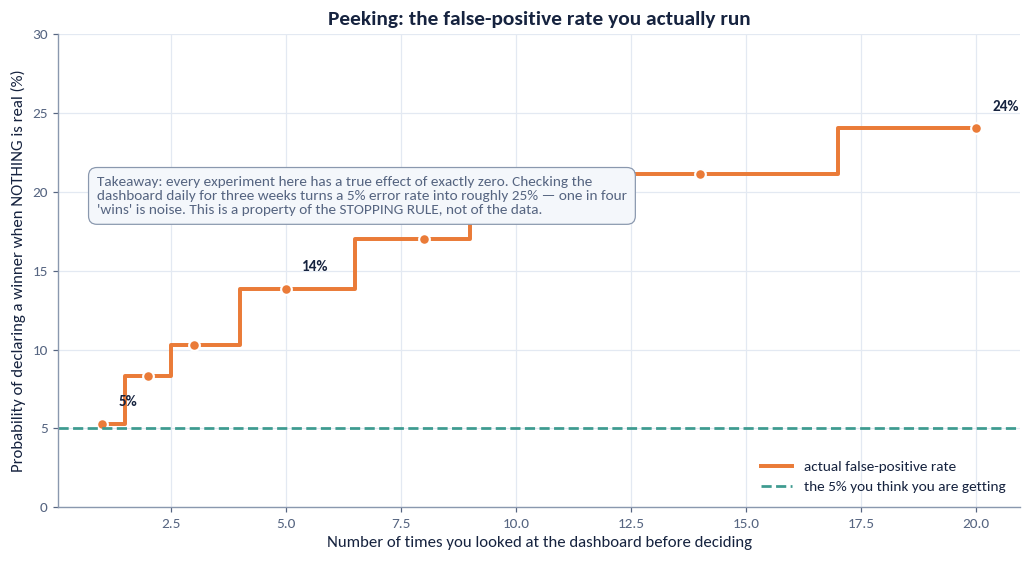

In [16]:
fine = my_peeking_simulation(n_looks_grid=(1, 2, 3, 5, 8, 10, 14, 20),
                             n_experiments=2_000)

fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.step(fine["n_looks"], 100 * fine["false_positive_rate"], where="mid",
        color=ORANGE, lw=2.6, label="actual false-positive rate")
ax.plot(fine["n_looks"], 100 * fine["false_positive_rate"], "o", color=ORANGE, ms=7,
        markeredgecolor="white", markeredgewidth=1.4)
ax.axhline(5, color=TEAL, ls="--", lw=1.8, label="the 5% you think you are getting")

for _, r in fine.iterrows():
    if int(r["n_looks"]) in (1, 5, 10, 20):
        ax.annotate(f"{100*r['false_positive_rate']:.0f}%",
                    xy=(r["n_looks"], 100 * r["false_positive_rate"]),
                    xytext=(r["n_looks"] + 0.35, 100 * r["false_positive_rate"] + 1.1),
                    fontsize=10, color=NAVY, fontweight="bold")

ax.set_xlabel("Number of times you looked at the dashboard before deciding")
ax.set_ylabel("Probability of declaring a winner when NOTHING is real (%)")
ax.set_title("Peeking: the false-positive rate you actually run")
ax.legend(loc="lower right")
ax.set_ylim(0, 30)
ax.annotate(
    "Takeaway: every experiment here has a true effect of exactly zero. Checking the\n"
    "dashboard daily for three weeks turns a 5% error rate into roughly 25% — one in four\n"
    "'wins' is noise. This is a property of the STOPPING RULE, not of the data.",
    xy=(0.04, 0.62), xycoords="axes fraction", fontsize=10, color=SLATE,
    bbox=dict(boxstyle="round,pad=0.55", fc=PANEL, ec=MUTED, lw=0.8))
plt.tight_layout()
plt.show()

> ### Instructor note — Step 7
>
> **Teaching point.** The numbers land at **5.3% → 13.9% → 18.4% → 24.1%** for 1/5/10/20
> looks. Ask the room to hold two facts at once: every one of those experiments had a true
> effect of zero, and one in four of the twenty-look runs declared a winner. This is a
> property of the *stopping rule*, not of the data — which is why no amount of extra data
> fixes it.
>
> **Common wrong answer.** "So we just need a bigger sample before we start peeking."
> No — the inflation depends on the number of looks, not the sample size. Re-run with
> `n_per_arm=50_000` if someone insists; the curve barely moves.
>
> **When a participant is stuck.** The naive nested-loop version (re-running a t-test on
> growing arrays) takes several minutes. If someone's cell is hanging, that is why — point
> them at the cumulative-sum recipe in the docstring. **Fast finishers:** implement
> `causal_utils.always_valid_bound` and show that a confidence sequence holds 5% under
> continuous monitoring, at the cost of a wider interval early on.

---
## Step 8 *(8 min)* — Statistical significance is not a decision

You now have an effect, an honest interval, clean guardrails and no surviving segment
story. One question remains, and it is not a statistical one:

**Is the effect big enough to be worth shipping?**

The frozen plan set a **practical-significance threshold** of 1.0 pp — the smallest lift
that justifies the build and maintenance cost. Map the *interval* onto the decision, not
the p-value onto a verdict. There are four cases, and only one of them is "ship".


Completion rate (triggered users): +2.07 pp [+1.26, +2.88]  vs threshold +1.0 pp
  VERDICT: SHIP
  because the whole interval clears the 1.0 pp threshold.



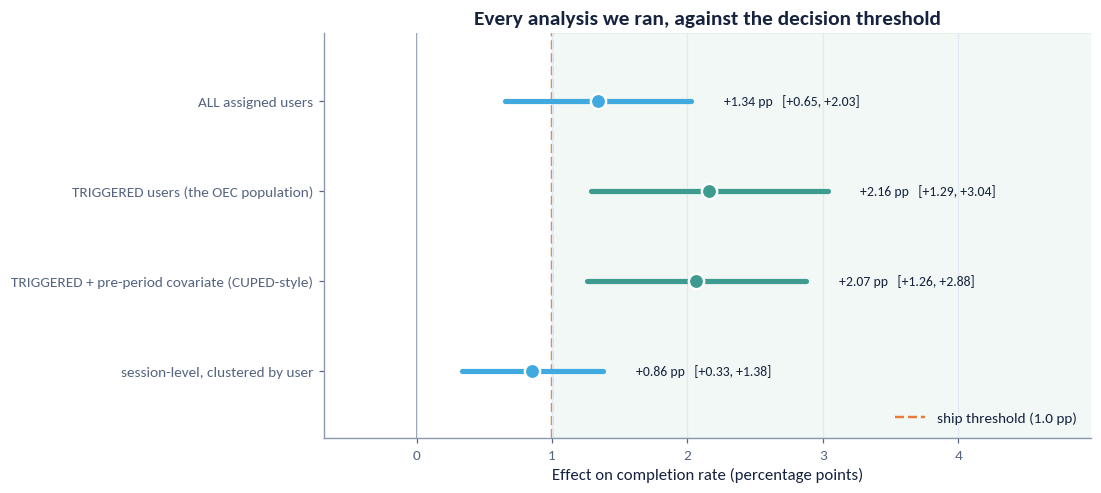


The four cases, and where we landed:
  entire interval above the threshold   -> SHIP                <- us
  entire interval below zero            -> STOP / ROLL BACK
  positive but entirely below threshold -> HOLD, real but too small
  interval straddles the threshold      -> HOLD, extend or accept the risk
  interval contains zero                -> INCONCLUSIVE (not 'no effect')


In [17]:
print(practical_significance_verdict(est_cuped, THRESHOLD,
                                    metric_name="Completion rate (triggered users)"))
print()
decision_plot([est_all, est_trig, est_cuped, clustered], threshold=THRESHOLD,
              title="Every analysis we ran, against the decision threshold")
plt.show()

print()
print("The four cases, and where we landed:")
print("  entire interval above the threshold   -> SHIP                <- us")
print("  entire interval below zero            -> STOP / ROLL BACK")
print("  positive but entirely below threshold -> HOLD, real but too small")
print("  interval straddles the threshold      -> HOLD, extend or accept the risk")
print("  interval contains zero                -> INCONCLUSIVE (not 'no effect')")

In [18]:
DECISION = decision_memo(
    title="Guided document uploader — ship decision",
    decision=PLAN["decision"],
    estimates={
        "Completion rate (triggered users, CUPED-adjusted)": est_cuped,
        "Completion rate (all assigned users, ITT)": est_all,
        "Session-level completion (clustered by user)": clustered,
    },
    threshold=THRESHOLD,
    recommendation=(
        f"SHIP. Among users who reach the document-upload step the guided uploader raises "
        f"service completion by {100*est_cuped.estimate:.2f} percentage points "
        f"(95% CI {100*est_cuped.ci_low:+.2f} to {100*est_cuped.ci_high:+.2f}). The entire "
        f"interval sits above the {100*THRESHOLD:.1f} pp threshold the committee set for "
        f"the build, so the decision does not depend on where in the interval the truth "
        f"lies. Step drop-off fell 1.6 pp, which is the mechanism. Time-to-complete rose "
        f"4.4 seconds on a 159-second baseline: statistically detectable on 49,653 users, "
        f"not material to a citizen, and we recommend accepting it explicitly rather than "
        f"treating it as a breach."),
    assumptions=[
        "Assignment was by user hash and passed SRM (chi2 = 0.16, p = 0.69); the arms are "
        "balanced on every pre-treatment covariate we measured.",
        "The OEC population is TRIGGERED users, as pre-registered. The all-assigned "
        "(intent-to-treat) figure of +1.34 pp is the right input to a capacity plan, not "
        "to this decision.",
        "prior_completion_rate is pre-treatment, so the CUPED adjustment cannot bias the "
        "estimate; it narrowed the interval by 13.5% in variance terms.",
        "SUTVA: we assume no meaningful spillover between users. Shared household devices "
        "would dilute the estimate, making this a conservative lower bound.",
    ],
    risks=[
        "Time-to-complete rose 4.4 s (p = 4.8e-08). Small, but it should be monitored "
        "post-launch in case it grows with the full population.",
        "The one segment surviving Benjamini-Hochberg (device=ios) is EXPLORATORY. "
        "It is not evidence of heterogeneity and must not drive targeting; its "
        "interval overlaps the platform-wide effect.",
        "The experiment ran for a fixed horizon of two weeks. Novelty effects beyond that "
        "window are not measured here.",
        "Effects below roughly 0.6 pp are outside what this design could resolve; we make "
        "no claim about them in either direction.",
    ],
    what_would_change_this=[
        "A pre-registered follow-up on iOS returning a materially "
        "different effect would justify segment-specific treatment.",
        "A post-launch rise in time-to-complete beyond ~15 seconds would turn an accepted "
        "cost into a genuine guardrail breach.",
        "Evidence of household-level spillover would mean the true effect is larger than "
        "reported, strengthening rather than weakening the recommendation.",
    ],
    plan=None,
)
print(DECISION)
print(f"(frozen analysis plan hash: {PLAN['plan_hash']})")

DECISION MEMO — Guided document uploader — ship decision
To: Injaz Product & Policy Committee
Date: 2026-09-07
Analysis plan frozen: not recorded  (hash not recorded)

DECISION REQUESTED
Ship the guided document uploader to all Injaz users, or keep the current plain uploader?

RECOMMENDATION
SHIP. Among users who reach the document-upload step the guided uploader raises service completion by 2.07 percentage points (95% CI +1.26 to +2.88). The entire interval sits above the 1.0 pp threshold the committee set for the build, so the decision does not depend on where in the interval the truth lies. Step drop-off fell 1.6 pp, which is the mechanism. Time-to-complete rose 4.4 seconds on a 159-second baseline: statistically detectable on 49,653 users, not material to a citizen, and we recommend accepting it explicitly rather than treating it as a breach.

WHAT WE MEASURED   (threshold for action: +1.0 pp)
  - Completion rate (triggered users, CUPED-adjusted): +2.07 pp (95% CI +1.26 to +2.88)
 

> ### Instructor note — Step 8

> **Teaching point.** The verdict function returns **SHIP** because the *whole* interval
> [+1.26, +2.88] clears the 1.0 pp threshold — which means the decision does not depend on
> where in the interval the truth lies. That is the sentence to teach: a decision is robust
> when it survives every value the data still permits, not when a p-value is small.
>
> **Set up the capstone here.** Say explicitly that the autofill experiment on Day 4 lands
> at +1.37 pp raw (+1.57 pp CUPED-adjusted) with an interval that *straddles* the same 1.0 pp threshold, and the correct
> answer there is **hold / extend**, not ship. A participant who writes "p < 0.05, ship it"
> has missed the entire course. Plant that now so it is not a surprise on Thursday.
>
> **Common wrong answer.** Reporting the memo with a p-value in it. `decision_memo`
> deliberately refuses to print one. A director cannot act on 0.0000000311; they can act on
> "between +1.3 and +2.9 points, and we need at least +1.0".
>
> **When a participant is stuck.** Give them the four-case ladder and ask which rung their
> interval sits on. If they cannot tell, the missing input is the threshold — which is a
> business number somebody should have written into the frozen plan, and in ours they did.


---
## Step 9 — Grade yourself against the planted ground truth

The uploader effect was planted at **+2.2 pp among triggered users**. Nothing in this
notebook was tuned to find it. Compare.


In [19]:
M4 = GROUND_TRUTH["module4_uploader_experiment"]

print(f"{'quantity':<46}{'recovered':>12}{'planted':>12}   verdict")
print("-" * 84)
rows = [
    ("effect on TRIGGERED users", est_trig.estimate, M4["true_lift_on_exposed"], 0.003),
    ("effect, CUPED-adjusted", est_cuped.estimate, M4["true_lift_on_exposed"], 0.003),
    ("effect on ALL assigned (diluted)", est_all.estimate, M4["true_lift_on_exposed"], 0.003),
    ("trigger rate", trigger_rate, M4["trigger_rate"], 0.005),
    ("treatment allocation", float((results.variant == "treatment").mean()),
     M4["allocation_treatment"], 0.002),
]
for name, got, want, tol in rows:
    print(f"{name:<46}{got:>12.4f}{want:>12.4f}   "
          f"{'MATCH' if abs(got - want) <= tol else 'MISSED — see below'}")

print()
print(f"The triggered estimate lands {abs(est_trig.estimate - M4['true_lift_on_exposed'])*100:.3f} pp "
      "from the planted truth.")
print(f"The all-assigned estimate misses it by "
      f"{abs(est_all.estimate - M4['true_lift_on_exposed'])*100:.2f} pp — and its 95% interval "
      f"[{100*est_all.ci_low:+.2f}, {100*est_all.ci_high:+.2f}] does not even contain +2.20 pp.")
print("That is what a population error costs. It is not noise, and it does not shrink.")
print()
print("Benchmarks for Module 4:")
print(f"  two-prop == OLS point estimate to 4 dp : "
      f"{abs(est_trig.estimate - est_ols.estimate) < 1e-4}")
print(f"  clustered SE wider than naive          : "
      f"{clustered.se > naive_sess.se}   ({clustered.se / naive_sess.se:.2f}x)")
print(f"  peeking FPR at 20 looks ~25%           : "
      f"{float(peek.loc[peek.n_looks == 20, 'false_positive_rate'].iloc[0]):.1%}")
print(f"  correction families applied            : Bonferroni (guardrails), BH (sweep)")

quantity                                         recovered     planted   verdict
------------------------------------------------------------------------------------
effect on TRIGGERED users                           0.0216      0.0220   MATCH
effect, CUPED-adjusted                              0.0207      0.0220   MATCH
effect on ALL assigned (diluted)                    0.0134      0.0220   MISSED — see below
trigger rate                                        0.6207      0.6207   MATCH
treatment allocation                                0.5007      0.5007   MATCH

The triggered estimate lands 0.037 pp from the planted truth.
The all-assigned estimate misses it by 0.86 pp — and its 95% interval [+0.65, +2.03] does not even contain +2.20 pp.
That is what a population error costs. It is not noise, and it does not shrink.

Benchmarks for Module 4:
  two-prop == OLS point estimate to 4 dp : True
  clustered SE wider than naive          : True   (1.61x)
  peeking FPR at 20 looks ~25%    

### Benchmark table for Module 4 (fill this in from your own run)

| Analysis | Estimate | 95% CI | Verdict |
|---|---|---|---|
| All assigned users (ITT) | | | |
| Triggered, two-proportion | | | |
| Triggered, CUPED-adjusted | | | |
| Session-level, no clustering | | | falsely narrow — wrong |
| Session-level, clustered | | | honest width |


---
## What you now own

In [20]:
print("""
TOOLKIT CONTRIBUTION — Lab 4
============================================================
Reusable artefacts you built and can lift into any project:

  The analysis GATE
      srm_check first, always. An SRM-failing experiment is not analysed.

  my_two_proportion(df, outcome, group)
      Difference in proportions with the pooled/unpooled asymmetry done
      right: pooled variance for the p-value, unpooled for the interval.

  The TRIGGERED-population discipline
      Read the frozen trigger definition before choosing a denominator.
      Analysing everyone dilutes a real effect by the trigger rate.

  Covariate-adjusted estimation (regression_effect + a PRE-treatment covariate)
      The same estimate with a 14% tighter variance - and the demonstration
      of what post-treatment covariates do to it.

  The correction-family decision
      One pre-registered OEC -> no correction.
      A guardrail family      -> Bonferroni (FWER).
      An exploratory sweep    -> Benjamini-Hochberg (FDR), and a survivor is
                                 still only a hypothesis.

  Cluster-robust analysis (regression_effect(..., cluster="user_id"))
      Mandatory whenever the analysis row is finer than the randomisation
      unit. The point estimate never moves; the honesty does.

  my_peeking_simulation(...)
      The 5% -> 25% exhibit. Run it live the next time someone screenshots a
      p = 0.03 on day three.

  The decision memo (decision_plot + decision_memo)
      Effect, interval, threshold, guardrails, and what you are NOT claiming.
      No p-values reach this page.

Carried forward:
  - Labs 5-6 lose randomisation entirely and must argue for identification.
  - The capstone reruns this exact pipeline on the autofill experiment, where
    the interval STRADDLES the 1.0 pp threshold and the right answer is
    'hold / extend', not 'ship'.
============================================================
""")


TOOLKIT CONTRIBUTION — Lab 4
Reusable artefacts you built and can lift into any project:

  The analysis GATE
      srm_check first, always. An SRM-failing experiment is not analysed.

  my_two_proportion(df, outcome, group)
      Difference in proportions with the pooled/unpooled asymmetry done
      right: pooled variance for the p-value, unpooled for the interval.

  The TRIGGERED-population discipline
      Read the frozen trigger definition before choosing a denominator.
      Analysing everyone dilutes a real effect by the trigger rate.

  Covariate-adjusted estimation (regression_effect + a PRE-treatment covariate)
      The same estimate with a 14% tighter variance - and the demonstration
      of what post-treatment covariates do to it.

  The correction-family decision
      One pre-registered OEC -> no correction.
      A guardrail family      -> Bonferroni (FWER).
      An exploratory sweep    -> Benjamini-Hochberg (FDR), and a survivor is
                                 

---
## Mini-exercises

### 1 · Quiz

1. Why does peeking inflate the false-positive rate?
2. When are clustered standard errors required?
3. Bonferroni vs Benjamini–Hochberg — which controls what, and when do you use each?
4. Why can a ratio metric not be t-tested as a mean?
5. Statistical vs practical significance — state the difference in one sentence each.

### 2 · Correction exercise

Eight secondary p-values: `[0.001, 0.011, 0.020, 0.033, 0.041, 0.049, 0.20, 0.55]`.
Apply Bonferroni and BH, by hand first and then in code. Which discoveries does each keep,
and why is the difference exactly what you would want for an exploratory family?

### 3 · The delta method — a ratio metric done properly

`completions per session` has a **random denominator**. A per-value t-test understates its
variance. Compute the effect on this ratio metric with the delta method and compare the
standard error against the naive one.

### 4 · Discussion

- A stakeholder screenshots a p = 0.03 on day 3 and wants to ship. What do you say, and
  what *would* let you legitimately act early?
- When is FDR the right choice over FWER for the Injaz metric families?


In [21]:
# --- Mini-exercise 2: Bonferroni vs BH -----------------------------------
secondary = [0.001, 0.011, 0.020, 0.033, 0.041, 0.049, 0.20, 0.55]
bonf = correct_pvalues(secondary, method="bonferroni", alpha=0.05)
bh8 = correct_pvalues(secondary, method="bh", alpha=0.05)
merged = bonf[["metric", "p_raw", "p_adjusted", "reject"]].merge(
    bh8[["metric", "p_adjusted", "reject"]], on="metric",
    suffixes=("_bonferroni", "_bh"))
print("Eight secondary p-values, m = 8\n")
print(merged.to_string(index=False))
print(f"\nBonferroni keeps {int(merged['reject_bonferroni'].sum())} discovery; "
      f"BH keeps {int(merged['reject_bh'].sum())}.")
print("Bonferroni controls P(ANY false positive) and pays for it in power. BH controls")
print("the expected SHARE of false positives among discoveries — the right trade when the")
print("output is a hypothesis list rather than a set of go/no-go gates.")

# --- Mini-exercise 3: the delta method -----------------------------------
print("\n\n--- Ratio metric: completions per session ---\n")
per_user = sessions.groupby(["user_id", "variant"], as_index=False).agg(
    completions=("session_completed", "sum"), n_sessions=("session_id", "count"))


def ratio_delta(num, den):
    """Ratio estimate and its delta-method standard error."""
    num, den = np.asarray(num, float), np.asarray(den, float)
    n = len(num)
    mx, my = num.mean(), den.mean()
    vx, vy = num.var(ddof=1), den.var(ddof=1)
    cov = np.cov(num, den, ddof=1)[0, 1]
    ratio = mx / my
    var = (vx - 2 * (mx / my) * cov + (mx / my) ** 2 * vy) / (my ** 2 * n)
    return ratio, float(np.sqrt(var))


out = {}
for arm in ("treatment", "control"):
    sub = per_user.loc[per_user.variant == arm]
    out[arm] = ratio_delta(sub["completions"], sub["n_sessions"])

diff = out["treatment"][0] - out["control"][0]
se_delta = np.sqrt(out["treatment"][1] ** 2 + out["control"][1] ** 2)

# the naive alternative: treat each user's own ratio as an observation
per_user["user_ratio"] = per_user["completions"] / per_user["n_sessions"]
t_r = per_user.loc[per_user.variant == "treatment", "user_ratio"]
c_r = per_user.loc[per_user.variant == "control", "user_ratio"]
se_naive = np.sqrt(t_r.var(ddof=1) / len(t_r) + c_r.var(ddof=1) / len(c_r))

se_session = getattr(naive_sess, "se", None)   # from Step 6, if you ran it

print(f"ratio, treatment            : {out['treatment'][0]:.4f}")
print(f"ratio, control              : {out['control'][0]:.4f}")
print(f"difference                  : {diff:+.4f} completions per session\n")
print(f"{'variance estimator':<38}{'SE':>10}{'95% CI':>26}")
print("-" * 76)
print(f"{'delta method (user-clustered)':<38}{se_delta:>10.5f}"
      f"{f'[{diff - 1.96*se_delta:+.4f}, {diff + 1.96*se_delta:+.4f}]':>26}")
print(f"{'mean of per-user ratios':<38}{se_naive:>10.5f}"
      f"{f'[{diff - 1.96*se_naive:+.4f}, {diff + 1.96*se_naive:+.4f}]':>26}")
if se_session is not None:
    print(f"{'naive SESSION-level t-test (wrong)':<38}{se_session:>10.5f}"
          f"{f'[{diff - 1.96*se_session:+.4f}, {diff + 1.96*se_session:+.4f}]':>26}")
    print()
    print(f"The naive session-level interval is {se_delta / se_session:.1f}x too narrow: "
          "it treats")
    print("339,017 sessions as independent when there were only 80,000 coin flips.")
print()
print("The first two are both defensible and differ by ESTIMAND, not by correctness: the")
print("delta method targets E[completions] / E[sessions] (the platform ratio, denominator")
print("random), the mean-of-user-ratios weights a one-session user the same as a")
print("ten-session user. Decide which quantity the decision needs BEFORE you pick the")
print("estimator — most teams never notice they have silently chosen one.")

Eight secondary p-values, m = 8

metric  p_raw  p_adjusted_bonferroni  reject_bonferroni  p_adjusted_bh  reject_bh
test_1  0.001                  0.008               True       0.008000       True
test_2  0.011                  0.088              False       0.044000       True
test_3  0.020                  0.160              False       0.053333      False
test_4  0.033                  0.264              False       0.065333      False
test_5  0.041                  0.328              False       0.065333      False
test_6  0.049                  0.392              False       0.065333      False
test_7  0.200                  1.000              False       0.228571      False
test_8  0.550                  1.000              False       0.550000      False

Bonferroni keeps 1 discovery; BH keeps 2.
Bonferroni controls P(ANY false positive) and pays for it in power. BH controls
the expected SHARE of false positives among discoveries — the right trade when the
output is a hypothesis 

> ### Instructor note — mini-exercise answers
>
> **Quiz.** (1) Each look is another chance for noise to cross the threshold, so errors
> compound above α. (2) When the analysis unit is finer than the randomisation unit —
> sessions analysed, users randomised. (3) Bonferroni controls the family-wise error rate
> (probability of *any* false positive), BH controls the false discovery rate (expected
> *proportion* of false positives among discoveries); FWER for guardrails, FDR for
> exploratory sweeps. (4) Its denominator is random, so the variance of the ratio is not
> the variance of the numerator — use the delta method. (5) Statistical: the effect is
> distinguishable from zero. Practical: the effect is large enough to change what you do.
>
> **Correction exercise.** Bonferroni keeps **1** discovery (0.001 × 8 = 0.008 < 0.05);
> BH keeps **2** (0.011 × 8/2 = 0.044 < 0.05, while 0.020 × 8/3 = 0.053 just fails). The
> point is the gap, not the count: at m = 8 Bonferroni's adjusted values run to 8× the raw
> p, BH's to at most 8/rank×, so BH keeps hypotheses worth putting on next quarter's
> roadmap while Bonferroni keeps only what you would bet the guardrail on.
>
> **Delta method.** The delta-method SE and the mean-of-user-ratios SE differ because they
> estimate different estimands, not because one is "more correct" in the abstract. Ask which
> the decision needs: platform throughput (delta method) or the typical citizen's experience
> (mean of user ratios). Most teams never notice they have silently chosen.
>
> **Discussion.** For the day-3 screenshot: "That p-value is valid only if this was our
> only look, and it was not. Our pre-registered horizon is two weeks. If we need to be able
> to act early, we should have launched with a group-sequential or always-valid design —
> and we can do that on the *next* experiment." FDR beats FWER whenever the output is a
> ranked hypothesis list rather than a set of gates: segment sweeps, metric exploration,
> diagnostics. FWER stays for guardrails, where one missed harm is the expensive outcome.